DATA CLEANING

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [64]:
# load data
df = pd.read_csv('netflix_customer_churn.csv')
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [65]:
df.shape

(5000, 14)

In [66]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

FEATURE ENGINEERING

In [67]:
# create age column
def categorize_age(age):
    if age < 25: return "Under 25"
    elif 25 <= age <= 40: return "25-40 (Millennials)"
    elif 41 <= age <= 55: return "41-55 (Gen X)"
    else: return "56+ (Boomers)"

In [68]:
df['age_group'] = df['age'].apply(categorize_age)
df['age_group']

0             41-55 (Gen X)
1             41-55 (Gen X)
2       25-40 (Millennials)
3             41-55 (Gen X)
4             56+ (Boomers)
               ...         
4995               Under 25
4996          56+ (Boomers)
4997          56+ (Boomers)
4998          56+ (Boomers)
4999          56+ (Boomers)
Name: age_group, Length: 5000, dtype: object

In [69]:
# Watch Hours relative to Profile Count
df['hours_per_profile'] = round(df['watch_hours'] / df['number_of_profiles'], 2)

EDA(EXPLORATORY DATA ANALYSIS)

In [70]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre', 'age_group', 'hours_per_profile'],
      dtype='object')

In [71]:
# Churn Distribution
df['churned'].value_counts(normalize=True)

churned
1    0.503
0    0.497
Name: proportion, dtype: float64

In [72]:
# Churn vs Watch Hours
df.groupby('churned')['watch_hours'].mean().round(2)

churned
0    17.45
1     5.92
Name: watch_hours, dtype: float64

In [73]:
#Last Login vs Churn
df.groupby('churned')['last_login_days'].mean().round(2)

churned
0    21.77
1    38.31
Name: last_login_days, dtype: float64

In [74]:
# Monthly Fee vs Churn
df.groupby('churned')['monthly_fee'].mean().round(2)

churned
0    14.25
1    13.13
Name: monthly_fee, dtype: float64

In [75]:
# Profiles vs Engagement
df.groupby('number_of_profiles')['watch_hours'].mean().round(2)

number_of_profiles
1    11.52
2    10.98
3    11.85
4    12.36
5    11.54
Name: watch_hours, dtype: float64

In [76]:
# Genre Preference
df['favorite_genre'].value_counts()

favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64

In [77]:
# Region wise users
df['region'].value_counts()

region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

In [78]:
# device usage
df['device'].value_counts()

device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

DATA VISUALISATION

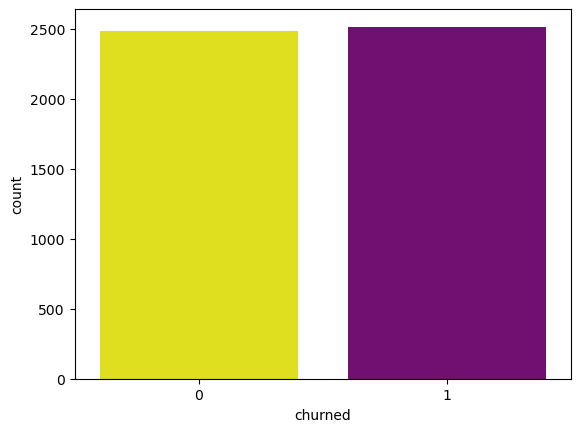

In [79]:
# Churn Distribution
sns.countplot(x='churned', data=df, palette=['yellow','purple'])
plt.show()

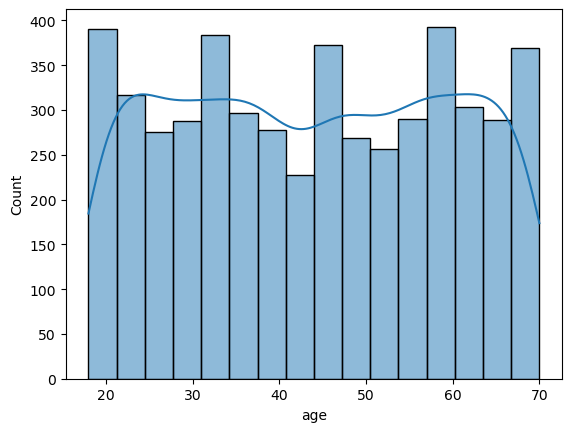

In [44]:
sns.histplot(df['age'], kde=True)
plt.show()

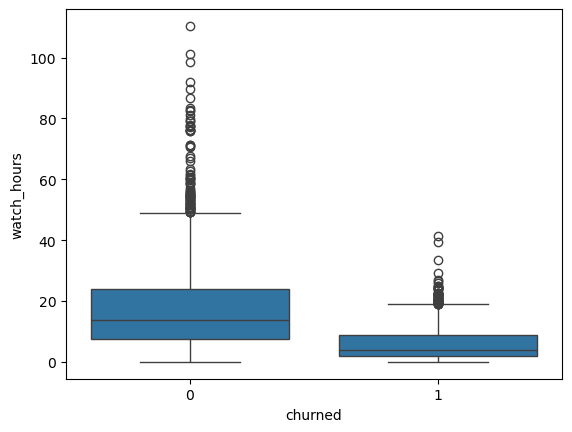

In [60]:
sns.boxplot(x='churned', y='watch_hours', data=df)
plt.show()

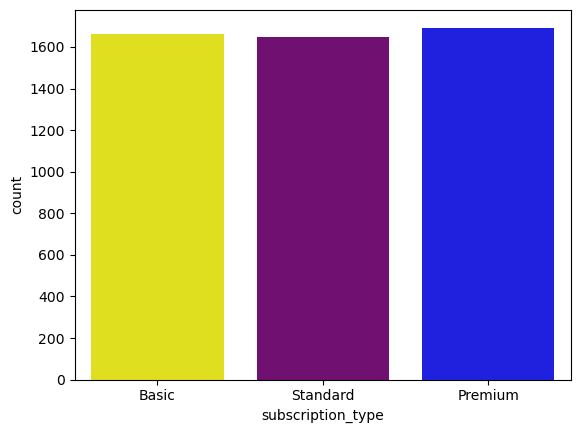

In [80]:
sns.countplot(x='subscription_type', data=df,palette=['yellow','purple','blue'])
plt.show()

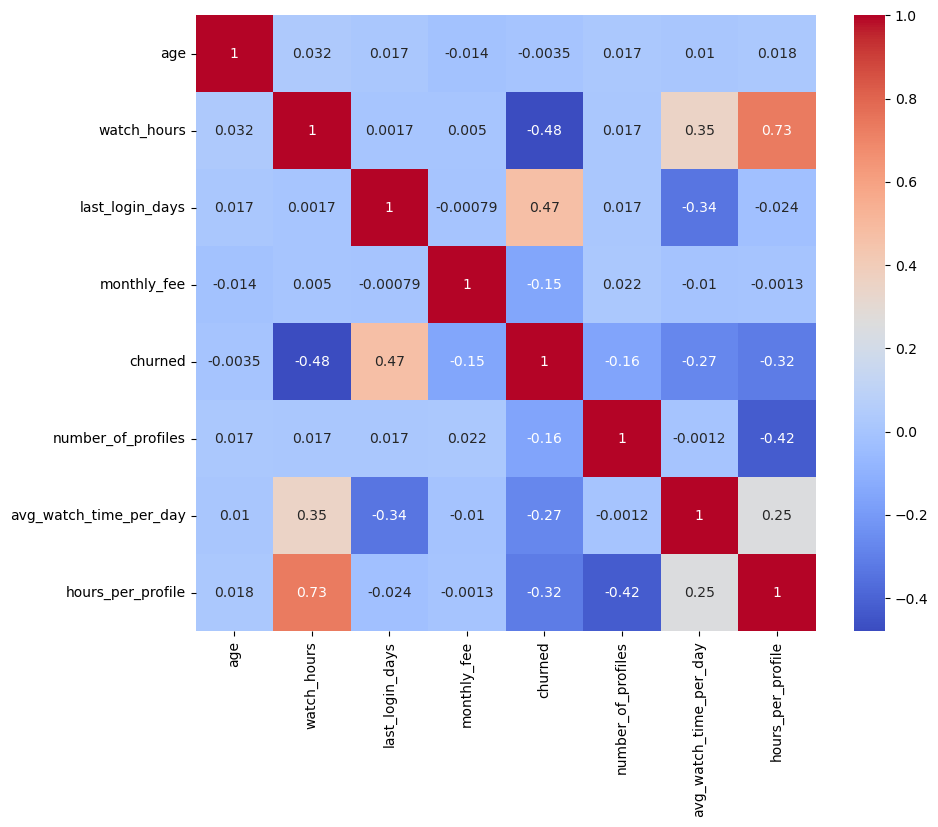

In [62]:
# correlations
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True,cmap='coolwarm')
plt.show()

CONNECT WITH SQL

In [9]:
pip install mysql-connector-python sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [10]:
from sqlalchemy import create_engine
engine = create_engine("mysql+mysqlconnector://root@localhost/netflix")

In [82]:
df.to_sql(name='netflix_cust', con=engine, if_exists='replace', index=False)

DatabaseError: (mysql.connector.errors.DatabaseError) 2003 (HY000): Can't connect to MySQL server on 'localhost:3306' (10061)
(Background on this error at: https://sqlalche.me/e/20/4xp6)

In [ ]:
df.to_csv("output.csv", index=False)


In [ ]:
import os
os.getcwd()